In [3]:
import pandas as pd
import numpy as np

In [4]:
%reload_ext sql

In [5]:
sale_df = pd.read_csv('sales.csv')
products_df = pd.read_csv('products.csv')
customers_df = pd.read_csv('customers.csv')

In [17]:
df = pd.merge(pd.merge(sale_df,products_df,on='product_id'),customers_df,on='customer_id')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df

,sale_id,customer_id,product_id,transaction_date,quantity,total_amount,product_name,category,price,launch_date,brand,first_name,last_name,age,state,income,registration_date,email
0,1,1,1,2022-02-10 14:30:00,1,79.99,Wireless Bluetooth Headphones,Electronics,79.99,2021-03-15,AudioTech,John,Smith,34,CA,75000,2022-01-15,john.smith@email.com
1,2,2,3,2022-02-15 10:15:00,2,39.98,Stainless Steel Water Bottle,Home & Garden,19.99,2021-05-10,HydroLife,Sarah,Johnson,28,NY,82000,2022-01-22,sarah.johnson@email.com
2,3,3,5,2022-02-20 16:45:00,1,34.99,Yoga Mat Premium,Sports & Outdoors,34.99,2021-06-15,FitZone,Michael,Brown,45,TX,95000,2022-02-03,michael.brown@email.com
3,4,4,2,2022-02-25 11:20:00,3,74.97,Organic Cotton T-Shirt,Clothing,24.99,2021-04-20,EcoWear,Emily,Davis,31,FL,68000,2022-02-14,emily.davis@email.com
4,5,5,4,2022-03-01 13:10:00,1,89.99,Leather Crossbody Bag,Accessories,89.99,2021-06-01,StyleCraft,David,Wilson,52,IL,110000,2022-02-28,david.wilson@email.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,86,30,2024-02-15 15:20:00,1,34.99,Wallet Minimalist,Accessories,34.99,2022-06-01,SlimLine,Kathryn,Alexander,27,CA,66000,2023-09-29,kathryn.alexander@email.com
146,147,87,32,2024-02-20 11:30:00,3,83.97,Candle Set Aromatherapy,Home & Garden,27.99,2022-06-28,RelaxScents,Harold,Russell,48,NY,99000,2023-10-06,harold.russell@email.com
147,148,88,34,2024-02-25 13:45:00,2,109.98,Hoodie Pullover,Clothing,54.99,2022-07-23,ComfortWear,Sara,Griffin,35,TX,81000,2023-10-13,sara.griffin@email.com
148,149,89,36,2024-03-01 16:15:00,1,29.99,Basketball Official,Sports & Outdoors,29.99,2022-08-18,CourtKing,Arthur,Diaz,43,FL,92000,2023-10-20,arthur.diaz@email.com


In [9]:
import matplotlib.pyplot as plt

In [8]:
import seaborn as sns
import pandas as pd
sns.set_style("whitegrid")
sns.set_context("notebook")

In [11]:
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print(df.head())

Dataset shape: (150, 18)

Column names: ['sale_id', 'customer_id', 'product_id', 'transaction_date', 'quantity', 'total_amount', 'product_name', 'category', 'price', 'launch_date', 'brand', 'first_name', 'last_name', 'age', 'state', 'income', 'registration_date', 'email']
   sale_id  customer_id  product_id    transaction_date  quantity  \
0        1            1           1 2022-02-10 14:30:00         1   
1        2            2           3 2022-02-15 10:15:00         2   
2        3            3           5 2022-02-20 16:45:00         1   
3        4            4           2 2022-02-25 11:20:00         3   
4        5            5           4 2022-03-01 13:10:00         1   

   total_amount                   product_name           category  price  \
0         79.99  Wireless Bluetooth Headphones        Electronics  79.99   
1         39.98   Stainless Steel Water Bottle      Home & Garden  19.99   
2         34.99               Yoga Mat Premium  Sports & Outdoors  34.99   
3       

In [12]:
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())


Data types:
sale_id                       int64
customer_id                   int64
product_id                    int64
transaction_date     datetime64[us]
quantity                      int64
total_amount                float64
product_name                    str
category                        str
price                       float64
launch_date                     str
brand                           str
first_name                      str
last_name                       str
age                           int64
state                           str
income                        int64
registration_date               str
email                           str
dtype: object

Basic statistics:


          sale_id  customer_id  product_id     transaction_date    quantity  \
count  150.000000   150.000000  150.000000                  150  150.000000   
mean    75.500000    39.500000   28.033333  2023-02-22 00:02:28    1.980000   
min      1.000000     1.000000    1.000000  2022-02-10 14:30:00    1.000000   
25%     38.250000    19.250000   12.250000  2022-08-16 17:33:45    1.000000   
50%     75.500000    38.000000   27.000000  2023-02-23 02:07:30    2.000000   
75%    112.750000    56.750000   42.750000  2023-08-30 18:52:30    3.000000   
max    150.000000    90.000000   60.000000  2024-03-05 10:30:00    5.000000   
std     43.445368    24.141293   17.533254                  NaN    1.083556   

       total_amount       price         age         income  
count    150.000000  150.000000  150.000000     150.000000  
mean      89.393533   57.263333   36.966667   83480.000000  
min       12.990000    9.990000   26.000000   63000.000000  
25%       48.465000   24.990000   31.000000 

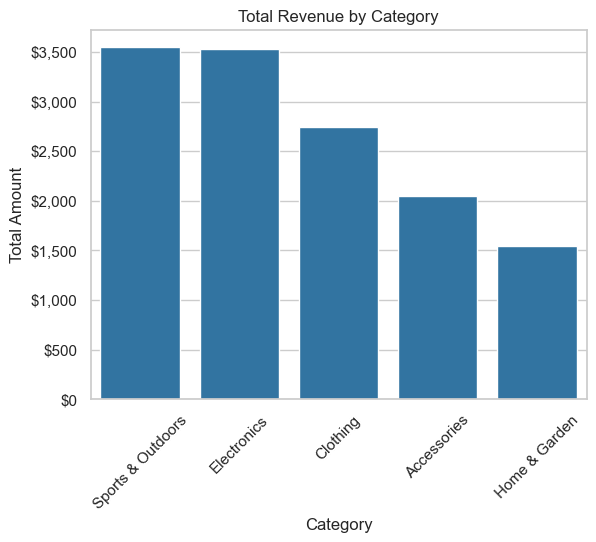

In [44]:
##Chart 1: Revenue by Product Category
#1 Create a horizontal bar chart showing total revenue for each product category
#2 Sort categories from highest to lowest revenue
#3 Use clear, professional styling with proper labels
#4 Format the x-axis to show currency values

#count/barplot(data, x, y, hue, order, hue_order, orient, color, palette, saturation, fill, hue_norm, stat, width, dodge, gap, log_scale, native_scale, formatter, legend, ax, **kwargs)
result = df.groupby(["category"])['total_amount'].aggregate(np.sum).reset_index().sort_values('total_amount',ascending=False)
ax = sns.barplot(x="category", y="total_amount", data=df, estimator=sum, errorbar=None, order=result['category'])
plt.title("Total Revenue by Category")
plt.xticks(rotation=45)
ax.set(xlabel='Category', ylabel='Total Amount')

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.show()


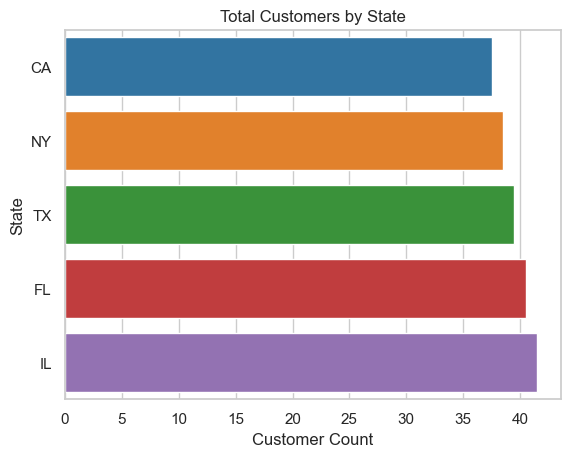

In [11]:
##Chart 2: Customer Distribution by State
#1 Build a horizontal bar chart showing customer counts by state
#2 Display only the top 6 states to keep the chart readable
#3 Add clear titles and labels explaining what the data represent

df.groupby(["state"])['customer_id'].aggregate(np.sum).head(6).reset_index()
ax = sns.barplot(x="customer_id", y="state", hue="state", data=df, errorbar=None)
plt.title("Total Customers by State")
ax.set(xlabel='Customer Count', ylabel='State')
plt.show()

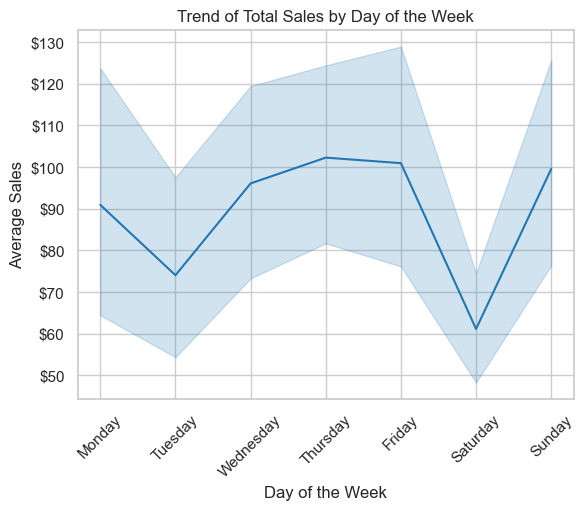

In [45]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['transaction_day'] = df['transaction_date'].dt.day_name()
df.groupby(["transaction_day"])['total_amount'].aggregate(np.mean)
df['transaction_day'] = pd.Categorical(df['transaction_day'], categories=weekday_order, ordered=True)
ax = sns.lineplot(data=df, y="total_amount", x="transaction_day")
plt.title("Trend of Total Sales by Day of the Week")
ax.set(xlabel='Day of the Week', ylabel='Average Sales')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=45)
plt.show()

C:\Users\Todd\AppData\Local\Temp\ipykernel_22304\1549309910.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Avg Transaction Values")


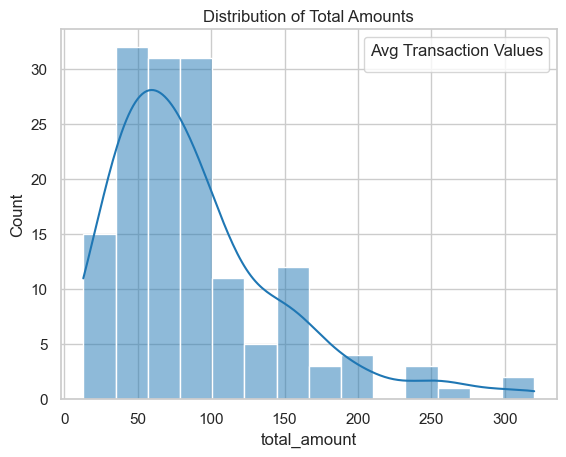

In [51]:
sns.histplot(data=df, x="total_amount", kde=True)
plt.title("Distribution of Total Amounts")
plt.legend(title="Avg Transaction Values")
plt.show()